# 18 — Approximate partial order with coarser group axis (Greek-only)

* **Group axis** — `group_meta` atomic. ≈30 canonical group-types from prior Gemini runs.
* **Resource axis** — `resource_meta` bucketed down to ≈30 by collapsing near-duplicates (`own land` + `own property`, `retain property` + `retain earnings`, etc.).
* **Polity filter** — only rules whose `rule_polity` is an ancient Greek city-state, league, or Hellenistic Greek successor state. Roman, Egyptian, Persian, Carthaginian, Christian, etc. are dropped.
* **Group cleanups** — drop `Other`; merge `The poor` + `The multitude` into a single bucket.
* **Filter** — `directionality == 'MORE'` only.
* **Periods (3)** — `Classical`, `Late Classical`, `Roman` (= `Hellenistic & Early Roman` + `High Roman Empire`).
* **Relaxed inclusion** — A → B is drawn if `|rights(A) ∩ rights(B)| / |rights(A)| ≥ OVERLAP_MIN` and `|rights(B)| > |rights(A)|`.

In [27]:
from pathlib import Path
from itertools import combinations

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

DATA_PATH = Path('../data/rules_dataset_april_2026.tsv')

PERIOD_MAP = {
    'Classical (500–360 BCE)':                      'Classical (500–360 BCE)',
    'Late Classical (354–165 BCE)':                 'Late Classical (354–165 BCE)',
    'Hellenistic & Early Roman (165 BCE – 105 CE)': 'Roman (165 BCE – 205 CE)',
    'High Roman Empire (135–205 CE)':               'Roman (165 BCE – 205 CE)',
}
PERIOD_ORDER = [
    'Classical (500–360 BCE)',
    'Late Classical (354–165 BCE)',
    'Roman (165 BCE – 205 CE)',
]

# --- Greek polity filter ----------------------------------------------------
# Includes Athens (all variants), Sparta, generic Greece, named Greek city-states,
# Greek leagues, and Hellenistic successor polities (Macedonian / Seleucid).
GREEK_POLITIES = {
    'Classical Athens', 'Hellenistic Athens', 'Archaic Athens',
    'Archaic Athens (Solonic)', 'Archaic Athens (Draconian)',
    'Archaic Athens (Peisistratid)', 'Archaic Athens (Pre-Solonic)',
    'Classical Athens (Solonic)', 'Classical Athens (Cleisthenic)',
    'Classical Athens (Eleusis)', 'Classical Athens (The Four Hundred)',
    'Classical Athens (The Five Thousand)', 'Classical Athens (the Five Thousand)',
    'Classical Sparta', 'Sparta', 'Archaic Sparta',
    'Classical Greece', 'Ancient Greece', 'Hellenistic Greece', 'Hellenistic Greek states',
    'Classical Thebes', 'Syracuse', 'Sicyon', 'Corinth', 'Aegina',
    'Mantineia', 'Mytilene', 'Oreus', 'Acragas', 'Delphi', 'Crete',
    'Chalcidice', 'Salamis (Cyprus)', 'Ionia and Pontus', 'Tarsus',
    'League of Corinth', 'Achaean League', 'Delphic Amphictyonic League',
    'Hellenistic Macedon', 'Macedonian Empire', 'Seleucid Empire',
    'Hierapolis (Syria)', 'Hellenistic Hierapolis',
    'Mythological / legendary setting',
}

# --- Group cleanups ---------------------------------------------------------
GROUP_DROP   = {'Other'}
GROUP_RENAME = {'The poor': 'The poor / multitude', 'The multitude': 'The poor / multitude'}

# --- Resource_meta bucketing (43 → 32 buckets) ------------------------------
RESOURCE_BUCKET = {
    'Right to own land':                        'Right to own property',
    'Right to retain own earnings':             'Right to retain property',
    'Right to inherit divine covenant':         'Right to inherit',
    'Right to inherit property':                'Right to inherit',
    'Right to speak first in assembly':         'Right to address the assembly',
    'Right to valid professional opinion':      'Right to professional judgement',
    'Right to military protection':             'Right to bear arms / military protection',
    'Right to bear arms':                       'Right to bear arms / military protection',
    'Protection from arbitrary banishment':     'Protection from banishment / prosecution',
    'Protection from legal prosecution':        'Protection from banishment / prosecution',
    'Protection from capital punishment':       'Protection from capital / corporal punishment',
    'Protection from corporal punishment':      'Protection from capital / corporal punishment',
    'Exemption from compulsory public financing': 'Exemption from public financing',
    'Exemption from public service financing':    'Exemption from public financing',
}

# Drop group-categories below this many positive resource buckets in a period.
MIN_RIGHTS = 2

# Approximate-inclusion threshold (see hasse-build cell).
OVERLAP_MIN = 0.6

In [28]:
df_raw = pd.read_csv(DATA_PATH, sep='\t')
df_raw.shape, df_raw['directionality'].value_counts().to_dict()

((1011, 34), {'MORE': 549, 'LESS': 462})

In [29]:
def atoms(s):
    if pd.isna(s):
        return []
    return [x.strip() for x in str(s).split(';') if x.strip()]

base = (df_raw[df_raw['directionality'] == 'MORE']
          .dropna(subset=['period', 'group_meta', 'resource_meta', 'rule_polity'])
          .assign(period=lambda d: d['period'].map(PERIOD_MAP))
          .dropna(subset=['period']))

# Keep only ancient Greek polities
base = base[base['rule_polity'].isin(GREEK_POLITIES)]

# Bucket resource_meta (43 → 32)
base = base.assign(resource_bucket=base['resource_meta'].map(lambda r: RESOURCE_BUCKET.get(r, r)))

# Explode group_meta atoms, drop 'Other', merge 'The poor' / 'The multitude'
base = (base
          .assign(group_cat=base['group_meta'].apply(atoms))
          .explode('group_cat'))
base = base[~base['group_cat'].isin(GROUP_DROP)]
base = base.assign(group_cat=base['group_cat'].replace(GROUP_RENAME))

positive = base[['period', 'group_cat', 'resource_bucket']].dropna()
positive.shape

(491, 3)

In [30]:
positive.head()

,period,group_cat,resource_bucket
5,Roman (165 BCE – 205 CE),Foreigners,Right to citizenship
6,Roman (165 BCE – 205 CE),Nobles,Political power
7,Late Classical (354–165 BCE),Citizens,Political power
12,Late Classical (354–165 BCE),Slaves,Protection from enslavement
13,Late Classical (354–165 BCE),Women,Right to a dowry


In [31]:
group_cats       = sorted(positive['group_cat'].unique())
resource_buckets = sorted(positive['resource_bucket'].unique())
len(group_cats), len(resource_buckets)

(28, 33)

In [32]:
print('Group categories:')
print(group_cats)
print()
print('Resource buckets:')
print(resource_buckets)

Group categories:
['Artisans', 'Citizens', 'Elders', 'Exiles', 'Foreigners', 'Greeks', 'Heirs', 'Kings', 'Macedonians', 'Magistrates', 'Men', 'Minors', 'Nobles', 'Orphans', 'Philosophers', 'Physicians', 'Poets', 'Priests', 'Scythians', 'Sick', 'Slaves', 'Soldiers', 'Spartans', 'The educated', 'The poor / multitude', 'The wealthy', 'Wives', 'Women']

Resource buckets:
['Access to public honors', 'Access to religious rites', 'Access to the gymnasium', 'Eligibility for public office', 'Exemption from legal audit', 'Exemption from manual labor', 'Exemption from military service', 'Exemption from public financing', 'Exemption from taxes', 'Political power', 'Protection from banishment / prosecution', 'Protection from capital / corporal punishment', 'Protection from enslavement', 'Protection from public libel', 'Right to a dowry', 'Right to a legal trial', 'Right to address the assembly', 'Right to adopt', 'Right to bear arms / military protection', 'Right to bodily autonomy', 'Right to buri

## Long-format 0/1 table

In [33]:
attested = set(map(tuple, positive[['period', 'group_cat', 'resource_bucket']].drop_duplicates().values))

rights_long = pd.DataFrame(
    [(p, g, r, int((p, g, r) in attested))
     for p in PERIOD_ORDER
     for g in group_cats
     for r in resource_buckets],
    columns=['period', 'group_cat', 'resource_bucket', 'has_right'],
)
rights_long.shape

(2772, 4)

In [34]:
rights_long.head()

,period,group_cat,resource_bucket,has_right
0,Classical (500–360 BCE),Artisans,Access to public honors,0
1,Classical (500–360 BCE),Artisans,Access to religious rites,0
2,Classical (500–360 BCE),Artisans,Access to the gymnasium,0
3,Classical (500–360 BCE),Artisans,Eligibility for public office,0
4,Classical (500–360 BCE),Artisans,Exemption from legal audit,0


In [35]:
rights_long.groupby('period')['has_right'].agg(['sum', 'count']).reindex(PERIOD_ORDER)

,sum,count
period,,
Classical (500–360 BCE),92,924
Late Classical (354–165 BCE),103,924
Roman (165 BCE – 205 CE),57,924


## Hasse diagram — group categories ordered by resource_meta inclusion

In [36]:
def right_sets(period):
    sub = rights_long[(rights_long['period'] == period) & (rights_long['has_right'] == 1)]
    sets = {g: frozenset(grp['resource_bucket']) for g, grp in sub.groupby('group_cat')}
    return {g: s for g, s in sets.items() if len(s) >= MIN_RIGHTS}

{p: len(right_sets(p)) for p in PERIOD_ORDER}

{'Classical (500–360 BCE)': 17,
 'Late Classical (354–165 BCE)': 17,
 'Roman (165 BCE – 205 CE)': 13}

In [37]:
def approx_graph(sets, overlap_min=OVERLAP_MIN):
    """Build a DAG where A → B iff
       |A ∩ B| / |A| >= overlap_min  AND  |B| > |A|.
       Groups with identical right-sets collapse into one node."""
    classes = {}
    for g, s in sets.items():
        classes.setdefault(s, []).append(g)
    nodes = list(classes.keys())

    G = nx.DiGraph()
    for s in nodes:
        G.add_node(s, size=len(s))
    for a, b in combinations(nodes, 2):
        big, small = (b, a) if len(b) > len(a) else (a, b)
        if len(big) == len(small):
            continue
        overlap = len(small & big) / len(small)
        if overlap >= overlap_min:
            G.add_edge(small, big)
    # transitive reduction only valid on DAGs; ours is a DAG because edges always go to strictly larger sets
    return nx.transitive_reduction(G), classes

In [38]:
def layered_positions(G):
    levels = {}
    for n in G.nodes:
        levels.setdefault(len(n), []).append(n)
    pos = {}
    for y, nodes in levels.items():
        nodes = sorted(nodes, key=lambda s: sorted(s))
        for i, n in enumerate(nodes):
            x = (i + 1) / (len(nodes) + 1)
            pos[n] = (x, y)
    return pos

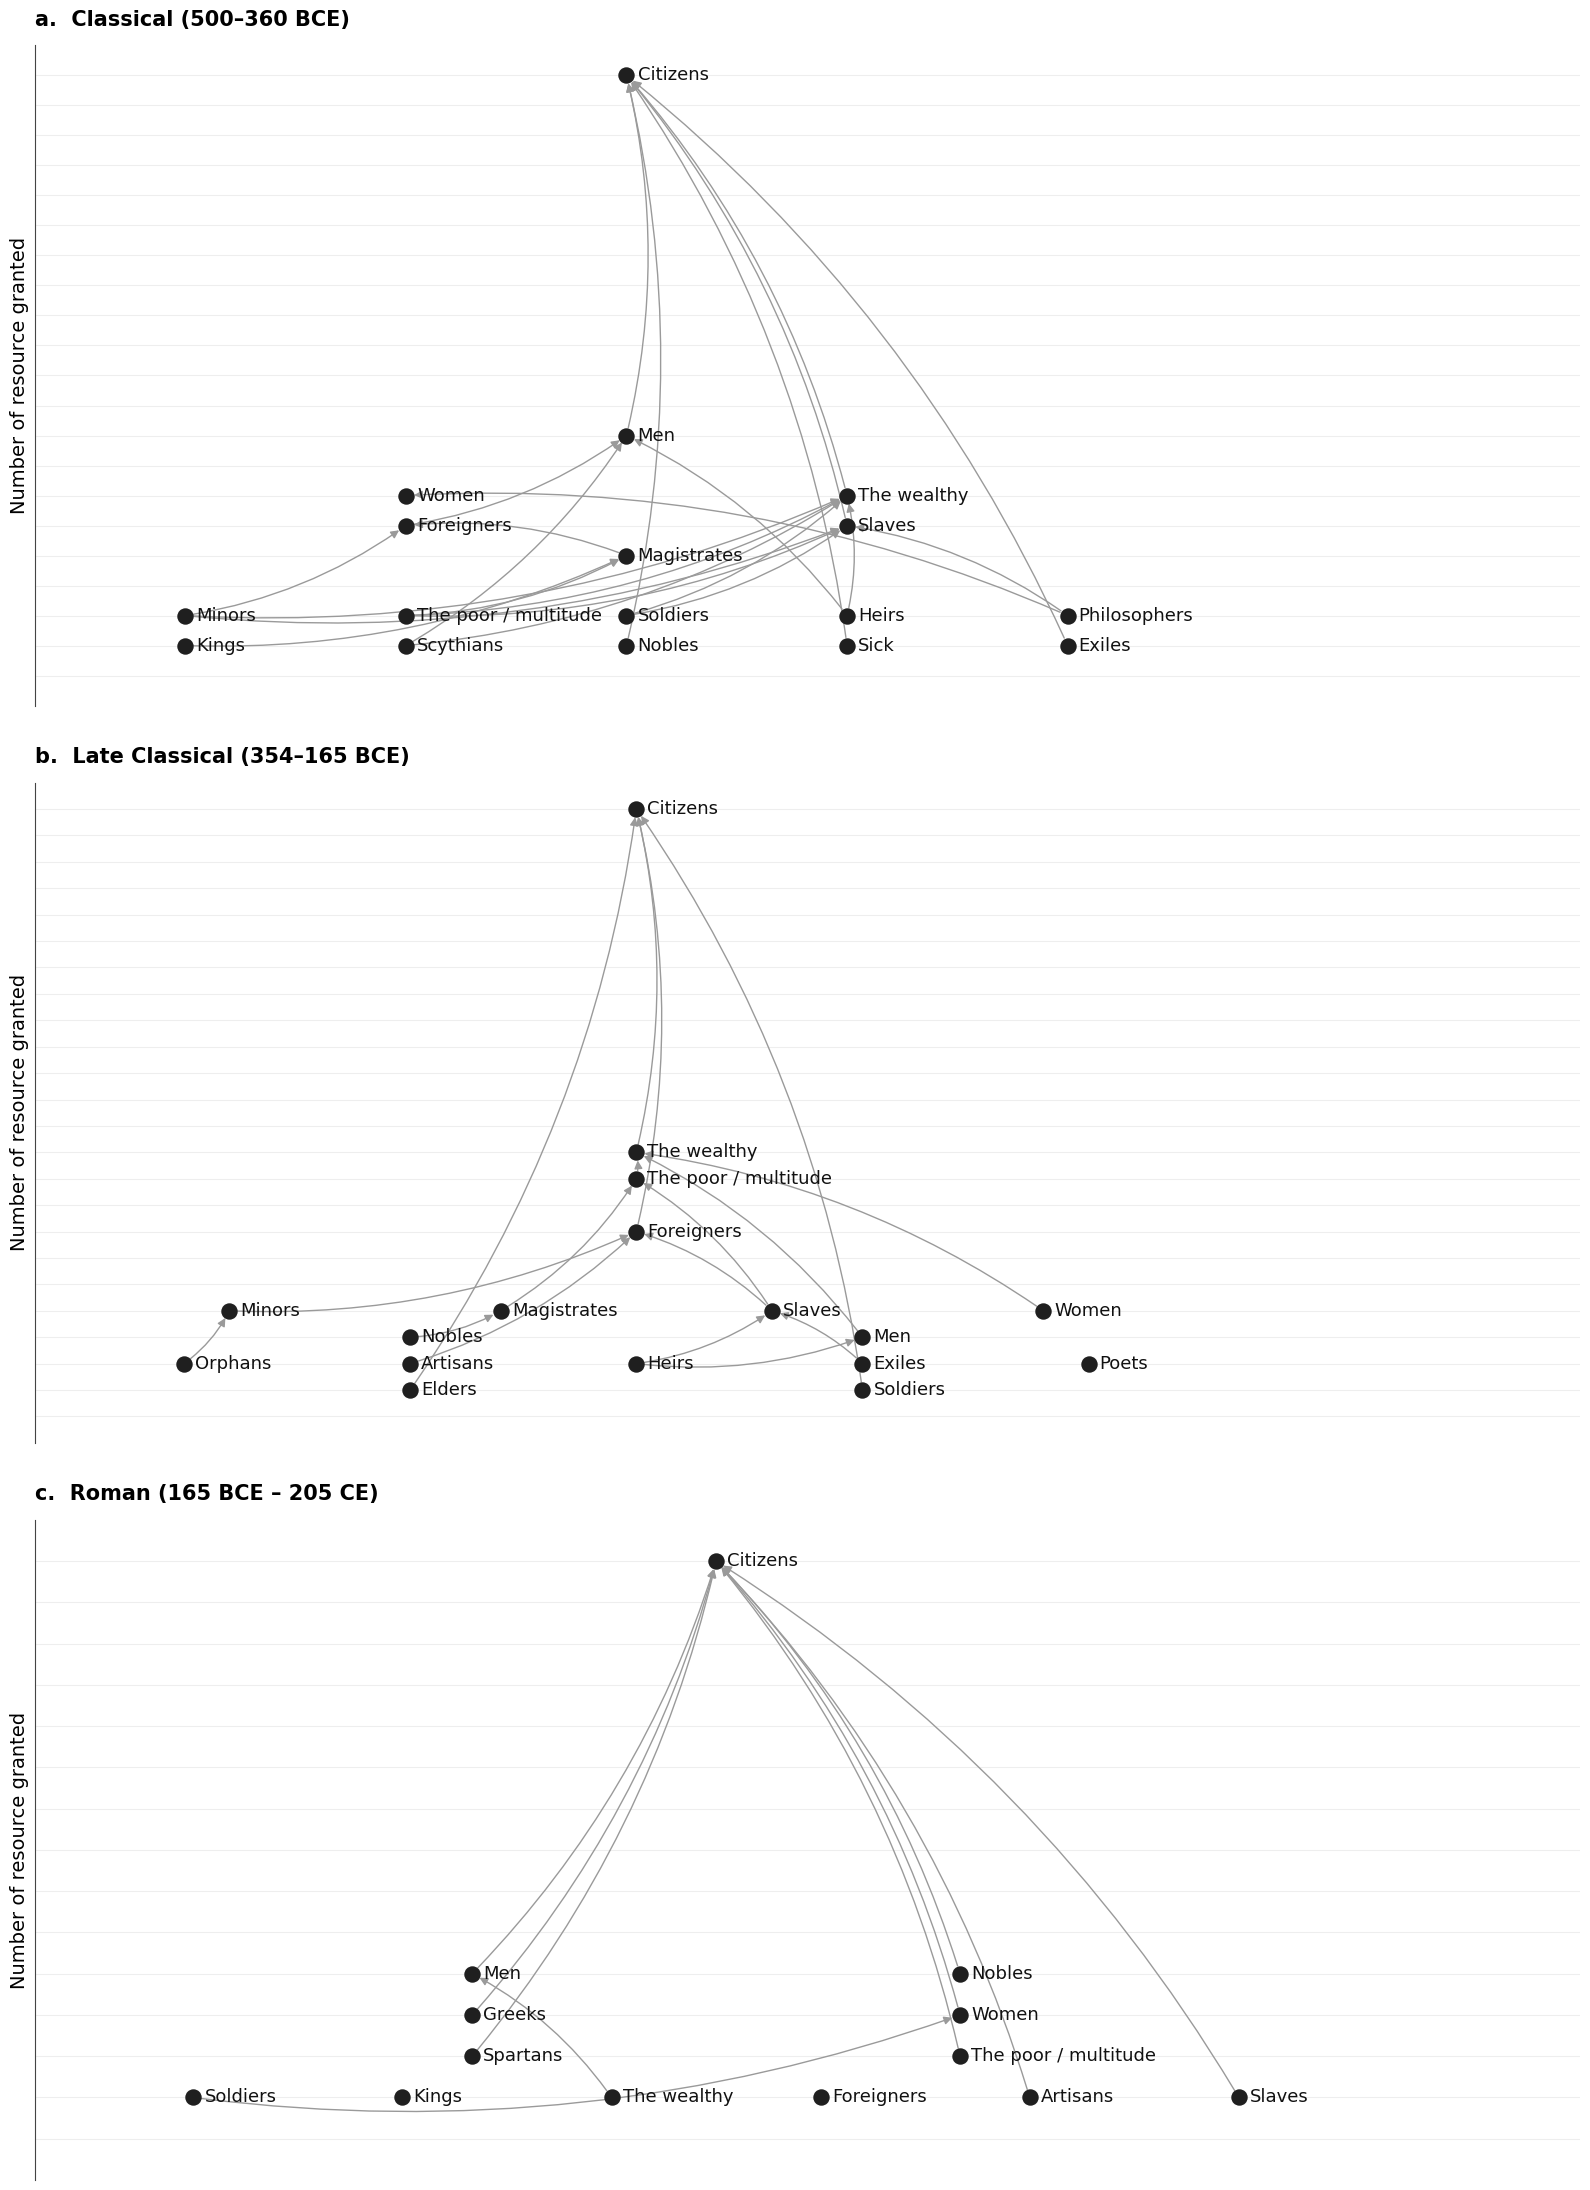

In [39]:
plt.rcParams.update({
    'font.family':     'DejaVu Sans',
    'axes.labelsize':  14,
    'axes.titlesize':  15,
    'xtick.labelsize': 11,
    'ytick.labelsize': 12,
})

NODE_SIZE = 140

fig, axes = plt.subplots(3, 1, figsize=(16, 22))

for letter, ax, period in zip('abc', axes, PERIOD_ORDER):
    sets = right_sets(period)
    G, classes = approx_graph(sets)
    pos = layered_positions(G)

    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_size=NODE_SIZE,
        node_color='#1f1f1f',
        linewidths=0,
    )
    nx.draw_networkx_edges(
        G, pos, ax=ax,
        edge_color='#9a9a9a',
        width=1.0,
        arrows=True,
        arrowstyle='-|>',
        arrowsize=12,
        node_size=NODE_SIZE,
        connectionstyle='arc3,rad=0.12',
        min_source_margin=4,
        min_target_margin=4,
    )

    for n, (x, y) in pos.items():
        ax.annotate(
            ', '.join(classes[n]),
            xy=(x, y), xytext=(8, 0),
            textcoords='offset points',
            ha='left', va='center',
            fontsize=13, color='#111111',
        )

    ymax = max(len(n) for n in G.nodes)
    ax.set_title(f'{letter}.  {period}', fontsize=15, loc='left', pad=14, weight='semibold')
    ax.set_ylabel('Number of resource granted')
    ax.set_yticks(range(1, ymax + 1))
    ax.set_ylim(0, ymax + 1)
    ax.set_xticks([])
    ax.tick_params(axis='y', length=0)
    ax.margins(x=0.08)
    ax.grid(axis='y', color='#eeeeee', linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ('top', 'right', 'bottom'):
        ax.spines[side].set_visible(False)
    ax.spines['left'].set_color('#444444')

fig.tight_layout(h_pad=3)
plt.show()